# 02 — Results Report

Generates the final comparison figures (saved to `../figures/`) backing `reports/final_report.md`.
All numbers here come directly from `src/evaluation.py`'s 5-fold CV run and the hybrid-blend
validation performed during modeling (see `TASKS.md` for the full derivation of each number).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Validated categorical palette (light mode) - see dataviz skill references/palette.md
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
})

## Figure 1 — 5-fold CV: model comparison

Mean RMSE +/- std across 5 folds, from `src/evaluation.py`'s `evaluate_cheap_models()` /
`mf_cv_summary()`. Lower is better. HybridModel isn't included here (it wasn't re-run through
full CV - see Figure 2 for its validated numbers instead).

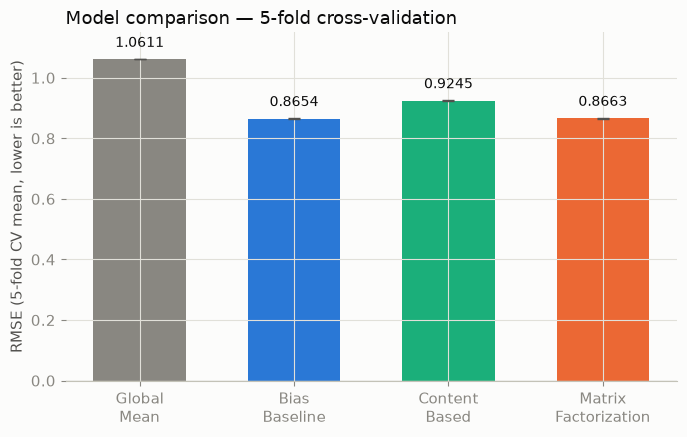

In [2]:
models = ['Global\nMean', 'Bias\nBaseline', 'Content\nBased', 'Matrix\nFactorization']
means = [1.0611, 0.8654, 0.9245, 0.8663]
stds = [0.0006, 0.0005, 0.0006, 0.0022]
colors = [INK_MUTED, BLUE, AQUA, ORANGE]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(models, means, yerr=stds, capsize=4, color=colors, width=0.6,
               error_kw={'ecolor': INK_SECONDARY, 'linewidth': 1.2})

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.03, f'{mean:.4f}',
            ha='center', va='bottom', fontsize=10, color=INK_PRIMARY)

ax.set_ylabel('RMSE (5-fold CV mean, lower is better)')
ax.set_title('Model comparison — 5-fold cross-validation', loc='left', fontsize=13, color=INK_PRIMARY)
ax.set_ylim(0, 1.15)
ax.axhline(0, color=BASELINE, linewidth=1)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_comparison_cv.png', dpi=150)
plt.show()

## Figure 2 — Why hybrid blending helps

"MF-only system" = MatrixFactorization for regular rows, falling back to BiasBaseline-equivalent
for cold-start rows (no per-item factor exists). "Hybrid system" blends in ContentBasedModel with
a weight that scales with the movie's training-rating count (see Figure 3). "Overall" is the
estimate weighted by test.csv's real composition (87.3% regular / 12.7% cold-start rows).
Numbers from the blend-weight validation in `src/models.py` (see TASKS.md 4c).

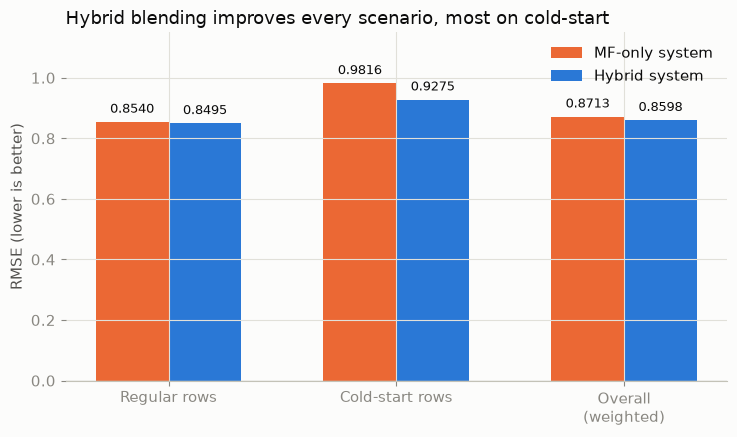

In [3]:
scenarios = ['Regular rows', 'Cold-start rows', 'Overall\n(weighted)']
mf_only = [0.8540, 0.9816, 0.8713]
hybrid = [0.8495, 0.9275, 0.8598]

x = np.arange(len(scenarios))
width = 0.32

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars1 = ax.bar(x - width/2, mf_only, width, label='MF-only system', color=ORANGE)
bars2 = ax.bar(x + width/2, hybrid, width, label='Hybrid system', color=BLUE)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.4f}',
                ha='center', va='bottom', fontsize=9.5, color=INK_PRIMARY)

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('Hybrid blending improves every scenario, most on cold-start', loc='left',
              fontsize=13, color=INK_PRIMARY)
ax.set_ylim(0, 1.15)
ax.legend(frameon=False, loc='upper right')
ax.axhline(0, color=BASELINE, linewidth=1)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/hybrid_impact.png', dpi=150)
plt.show()

## Figure 3 — Blend weight curve

`alpha(count) = max_alpha * count / (count + k)` (max_alpha=0.8, k=10), overlaid with the
empirical optimal blend weight found by grid search on held-out data per rating-count bucket
(see TASKS.md 4c). The curve is a smoothed fit, not an exact interpolation - the two large-sample
anchor points (0 ratings, 100+ ratings) are well-supported; the middle buckets have far fewer
validation rows and are noisier.

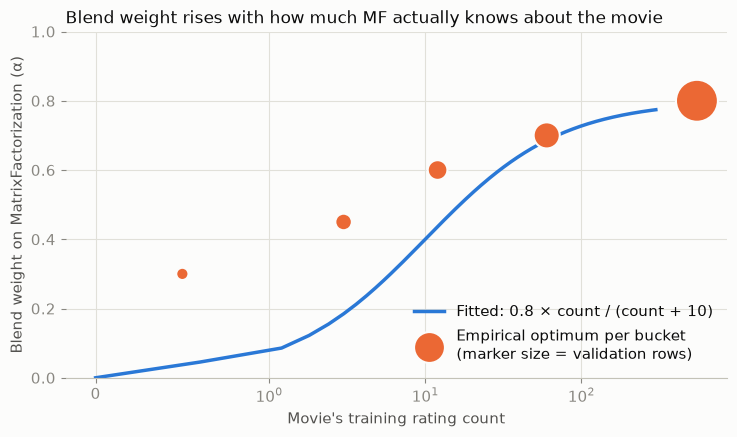

In [4]:
counts = np.linspace(0, 300, 500)
max_alpha, k = 0.8, 10.0
alpha_curve = max_alpha * counts / (counts + k)

# empirical grid-search results per rating-count bucket (midpoint used for x-position)
bucket_mid = [0.5, 3, 12, 60, 550]
bucket_alpha = [0.30, 0.45, 0.60, 0.70, 0.80]
bucket_n = [674, 2242, 4467, 13896, 92358]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(counts, alpha_curve, color=BLUE, linewidth=2.5, label='Fitted: 0.8 \u00d7 count / (count + 10)', zorder=2)
ax.scatter(bucket_mid, bucket_alpha, color=ORANGE, s=[n**0.5 * 3 for n in bucket_n],
           edgecolor=SURFACE, linewidth=1.5, zorder=3, label='Empirical optimum per bucket\n(marker size = validation rows)')

ax.set_xscale('symlog', linthresh=1)
ax.set_xlabel("Movie's training rating count")
ax.set_ylabel('Blend weight on MatrixFactorization (\u03b1)')
ax.set_title('Blend weight rises with how much MF actually knows about the movie', loc='left',
              fontsize=12.5, color=INK_PRIMARY)
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/blend_weight_curve.png', dpi=150)
plt.show()